In [ ]:
print("hello")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy import units as u
from astropy.coordinates import (
    CartesianRepresentation, CylindricalRepresentation,
    UnitSphericalRepresentation)

from screens.screen import Source, Screen1D, Telescope
from screens.fields import phasor
# A handy function to create extents to use with
from screens.visualization import axis_extent

# Construct the systems components

The screens.screen module lets us first define the components of the scintillometry system (pulsar, scattering screen, and telescope) and consider their interaction afterwards.

For this simple example, we will use a reference frame whose 
-axis points along the direct line of sight from Earth to the pulsar, and we will assume that the scattering screen and Earth are at rest in this reference frame. Although not yet necessary for defining the individual components, let’s already set the distances (from Earth) to the pulsar d_p 
and to the screen d_s.

In [ ]:
d_p = 0.5 * u.kpc
d_s = 0.25 * u.kpc

: 

## The Pulsar

Create the pulsar using the Source class. Its three-dimensional position and velocity vectors, "pos" and "vel", need to be given as Asropy CartesianRepresentation objects. By default, the position is zero. Note that this position does not include the distance; the Source object only defines the properties of the source and could in principle be observed from anywhere. The (scaled) brightness of the pulsar can be set using the "magnification" attribute; by default, this attribute is set to unity.

In [4]:
pulsar_vel = CartesianRepresentation(-300., 0., 0., unit=u.km/u.s)

pulsar = Source(vel=pulsar_vel)

print(pulsar)

<Source
    pos=(0., 0., 0.) AU,
    vel=(-300., 0., 0.) km / s,
    magnification=1.0>


## The Scattering Screen

Create the scattering screen using the Screen1D class with the following arguments:

The unit normal vector normal that defines the orientation of the screen. It points in the direction of the line of images formed by the screen and it is perpendicular to the direct line of sight from Earth to the pulsar. This should be an Astropy CartesianRepresentation object. Here, we use Astropy’s CylindricalRepresentation class to create the unit vector in the xy-plane of the reference frame (with the azimuth measured counterclockwise from the x-axis), and convert it to a CartesianRepresentation object using the to_cartesian() method.

The positions p of the lensed images along the line defined by normal, given as an Astropy Quantity object.

The velocities v of the images along that line (in this case all images have the same velocity, zero).

The array magnification containing the complex magnifications of the images.

In [ ]:
scr1_normal = CylindricalRepresentation(1., 67.*u.deg, 0.).to_cartesian() # angle perpendicular to the line of images, where the scattering happens
scr1_pos = np.array([-1., -0.25, 0., 0.5]) << u.au
scr1_vel = 0. * u.km/u.s
scr1_magnification = np.array([-0.1 - 0.1j,
                                0.5 - 0.2j,
                                0.8,
                                0.2 + 0.1j])

scr1 = Screen1D(normal=scr1_normal, p=scr1_pos, v=scr1_vel,
                magnification=scr1_magnification)

print(scr1)

<Screen1D
    normal=(0.39073113, 0.92050485, 0.) ,
    p=[-1.   -0.25  0.    0.5 ] AU,
    v=0.0 km / s,
    magnification=[-0.1-0.1j  0.5-0.2j  0.8+0.j   0.2+0.1j]>


In [6]:
print(scr1_pos)

[-1.   -0.25  0.    0.5 ] AU


## The Telescope

Finally, create the telescope using the Telescope class. The default argument values set its position and velocity to zero. Note that this object also has a magnification attribute (with a default value of unity), which can be thought of as the efficiency of the telescope.

In [6]:
telescope = Telescope()

print(telescope)

<Telescope
    pos=(0., 0., 0.) AU,
    vel=(0., 0., 0.) km / s,
    magnification=1.0>


## Generating observations using observe()
The observe() method can be used to quickly generate scintillometric observations. It is available on the Screen class (of which Telescope and Screen1D are subclasses) and it requires two arguments:

The source argument is the source of radiation that is being observed. This should be either a Source object (for simulating a direct observation) or a Screen object (for simulating an observation of a screen that is scattering radiation from a source behind it).

The distance argument is the physical distance at which source is being observed. It should be an Astropy Quantity object.

For example, here we simulate a direct observation of the pulsar from the telescope (i.e., ignoring the screen for now). As we can see, this returns another Telescope object, but one that has a source and a distance attribute.

In [7]:
telescope.observe(source=pulsar, distance=d_p)

<Telescope
    pos=(0., 0., 0.) AU,
    vel=(0., 0., 0.) km / s,
    magnification=1.0,
    source=<Source
        pos=(0., 0., 0.) AU,
        vel=(-300., 0., 0.) km / s,
        magnification=1.0>,
    distance=0.5 kpc>

To simulate an observation of the pulsar scattered by the screen, we first use the observe() method from the screen to the pulsar, creating an object that encodes the images of the pulsar on the screen, and then generate an observation of the resulting object from the telescope. Note that the distance should be the relative distance from the object that is being observed to the object that does the observing.

In [8]:
obs_scr1_pulsar = scr1.observe(source=pulsar, distance=d_p-d_s)
obs1 = telescope.observe(source=obs_scr1_pulsar, distance=d_s)

print(obs1)

<Telescope
    pos=(0., 0., 0.) AU,
    vel=(0., 0., 0.) km / s,
    magnification=1.0,
    source=<Screen1D
        normal=(0.39073113, 0.92050485, 0.) ,
        p=[-1.   -0.25  0.    0.5 ] AU,
        v=0.0 km / s,
        magnification=[-0.1-0.1j  0.5-0.2j  0.8+0.j   0.2+0.1j],
        source=<Source
            pos=(0., 0., 0.) AU,
            vel=(-300., 0., 0.) km / s,
            magnification=1.0>,
        distance=0.25 kpc>,
    distance=0.25 kpc>


Making an observation with observe() also gives access to a few key scintillometric quantities: the (complex) brightness of each path of radiation (the product of the magnifications of the source, screen, and telescope), the instantaneous geometric delay of the radiation following each path, and the time derivatives of those delays.

In [9]:
obs1.brightness

array([-0.1-0.1j,  0.5-0.2j,  0.8+0.j ,  0.2+0.1j])

In [10]:
obs1.tau

<Quantity [9.67697385, 0.60481087, 0.        , 2.41924346] us>

In [11]:
obs1.taudot

<Quantity [-7.58251751e-06, -1.89562938e-06,  0.00000000e+00,
            3.79125875e-06] us / s>

## Making the Dynamic Spectrum

Define the observing frequencies and times. Make sure they will be broadcast against one another correctly.

In [12]:
t = np.linspace(0, 90*u.min, 180)[:, np.newaxis]
f = np.linspace(315*u.MHz, 317*u.MHz, 200)

Find the geometric delays as a function of time from the tau and taudot attributes of obs1. Add two extra dimensions to accommodate the time and frequency dimensions.

In [17]:
tau0 = obs1.tau[:, np.newaxis, np.newaxis]
taudot = obs1.taudot[:, np.newaxis, np.newaxis]
tau_t = tau0 + taudot * t

Compute the dynamic wavefield and then the dynamic spectrum. Here, we use the phasor() function from screens.fields, which essentially computes np.exp(1j * (f * tau_t * u.cycle).to_value(u.rad)).

In [18]:
ph = phasor(f, tau_t)
brightness = obs1.brightness[:, np.newaxis, np.newaxis]
dynwave = ph * brightness

dynspec = np.abs(dynwave.sum(axis=0))**2

Plot the dynamic spectrum.

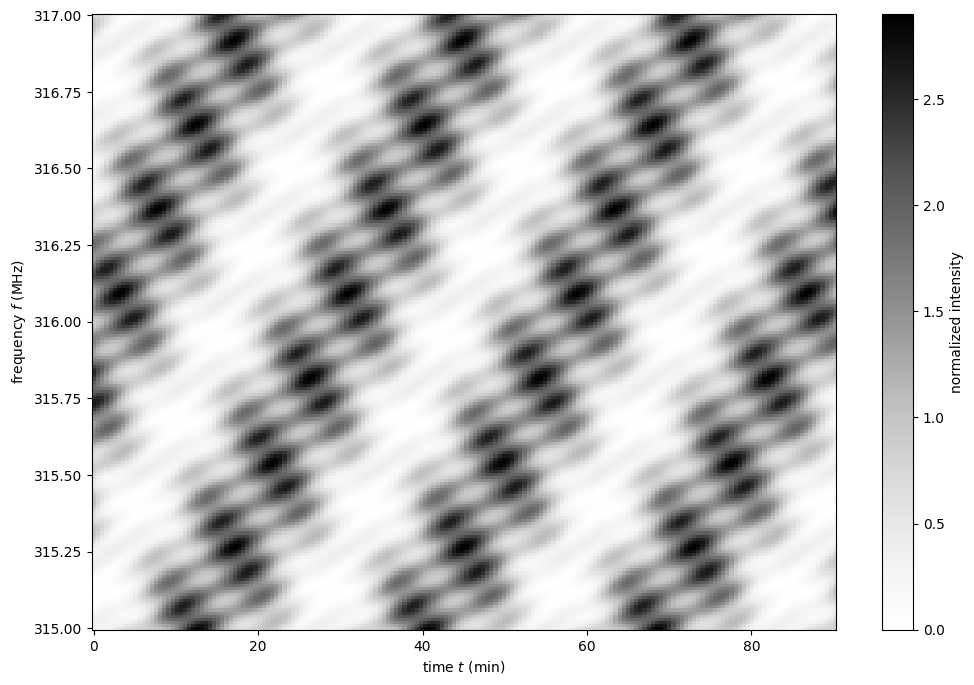

In [21]:
plt.figure(figsize=(12., 8.))

plt.imshow(dynspec.T,
           origin='lower', aspect='auto', interpolation='none',
           cmap='Greys', extent=axis_extent(t, f), vmin=0.)
plt.xlabel(rf"time $t$ ({t.unit.to_string('latex')})")
plt.ylabel(rf"frequency $f$ ({f.unit.to_string('latex')})")

cbar = plt.colorbar()
cbar.set_label('normalized intensity')

## Make the secondary spectrum

Compute the conjugate spectrum, the conjugate variables, and then the secondary spectrum.

In [22]:
conjspec = np.fft.fft2(dynspec)
conjspec /= conjspec[0, 0]
conjspec = np.fft.fftshift(conjspec)

tau = np.fft.fftshift(np.fft.fftfreq(f.size, f[1]-f[0])).to(u.us)
fd = np.fft.fftshift(np.fft.fftfreq(t.size, t[1]-t[0])).to(u.mHz)

secspec = np.abs(conjspec)**2

Plot the secondary spectrum.

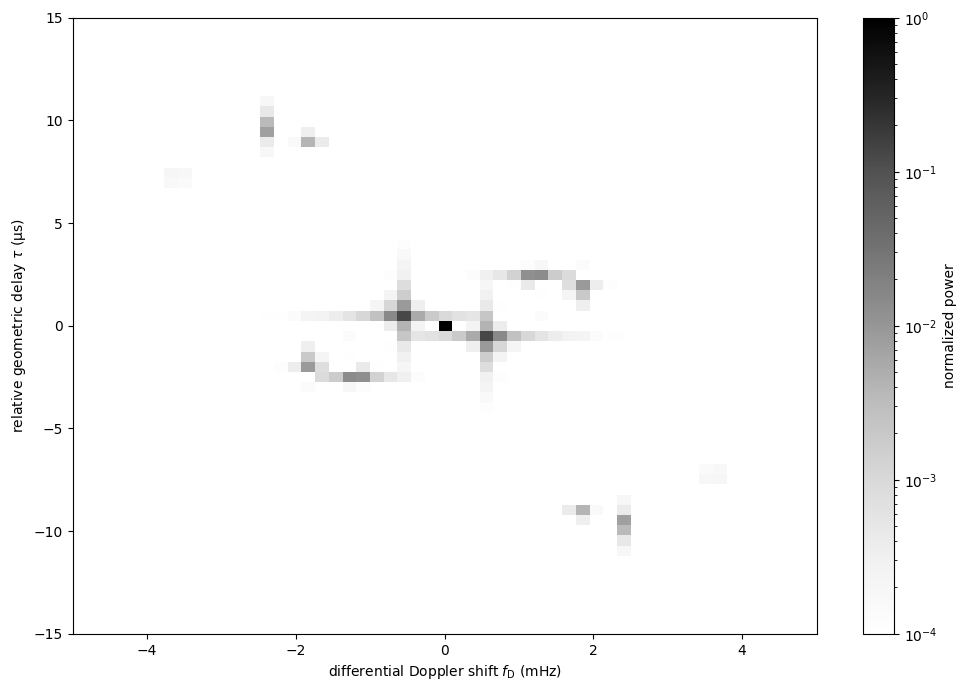

In [23]:
plt.figure(figsize=(12., 8.))

plt.imshow(secspec.T,
           origin='lower', aspect='auto', interpolation='none',
           cmap='Greys', extent=axis_extent(fd, tau),
           norm=LogNorm(vmin=1.e-4, vmax=1.))
plt.xlim(-5., 5.)
plt.ylim(-15., 15.)
plt.xlabel(r"differential Doppler shift $f_\mathrm{{D}}$ "
           rf"({fd.unit.to_string('latex')})")
plt.ylabel(r"relative geometric delay $\tau$ "
           rf"({tau.unit.to_string('latex')})")

cbar = plt.colorbar()
cbar.set_label('normalized power')

plt.show()

## Visualize the system

Here is a bit of code that generates a 3D sketch of the system.

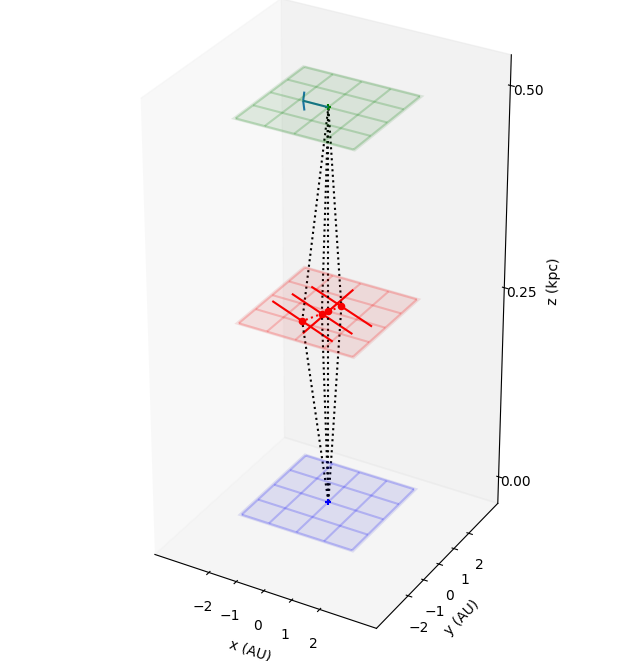

In [24]:
def unit_vector(c):
    return c.represent_as(UnitSphericalRepresentation).to_cartesian()

ZHAT = CartesianRepresentation(0., 0., 1., unit=u.one)

def plot_screen(ax, s, d, color='black', **kwargs):
    d = d.to_value(u.kpc)
    x = np.array(ax.get_xlim3d())
    y = np.array(ax.get_ylim3d())[:, np.newaxis]
    ax.plot_surface([[-2.1, 2.1]]*2, [[-2.1]*2, [2.1]*2], d*np.ones((2, 2)),
                    alpha=0.1, color=color)
    x = ax.get_xticks()
    y = ax.get_yticks()[:, np.newaxis]
    ax.plot_wireframe(x, y, np.broadcast_to(d, (x+y).shape),
                    alpha=0.2, color=color)
    spos = s.normal * s.p if isinstance(s, Screen1D) else s.pos
    ax.scatter(spos.x.to_value(u.AU), spos.y.to_value(u.AU), d,
               c=color, marker='+')
    if spos.shape:
        for pos in spos:
            zo = np.arange(2)
            ax.plot(pos.x.to_value(u.AU)*zo, pos.y.to_value(u.AU)*zo,
                    np.ones(2) * d, c=color, linestyle=':')
            upos = pos + (ZHAT.cross(unit_vector(pos)) * ([-1.5, 1.5] * u.AU))
            ax.plot(upos.x.to_value(u.AU), upos.y.to_value(u.AU),
                    np.ones(2) * d, c=color, linestyle='-')
    elif s.vel.norm() != 0:
        dp = s.vel * 5 * u.day
        ax.quiver(spos.x.to_value(u.AU), spos.y.to_value(u.AU), d,
                dp.x.to_value(u.AU), dp.y.to_value(u.AU), np.zeros(1),
                arrow_length_ratio=0.05)
plt.figure(figsize=(8., 12.))
ax = plt.subplot(111, projection='3d')
ax.set_box_aspect((1, 1, 2))
# ax.set_axis_off()
ax.grid(False)
ax.set_xlim3d(-4, 4)
ax.set_ylim3d(-4, 4)
ax.set_xticks([-2, -1, 0, 1., 2])
ax.set_yticks([-2, -1, 0, 1., 2])
ax.set_zticks([0, d_s.value, d_p.value])
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_zlabel('z (kpc)', labelpad=12)
plot_screen(ax, telescope, 0*u.kpc, color='blue')
plot_screen(ax, scr1, d_s, color='red')
plot_screen(ax, pulsar, d_p, color='green')

path_shape = obs1.tau.shape
tpos = obs1.pos
scat1 = obs1.source.pos
ppos = obs1.source.source.pos
x = np.vstack(
    [np.broadcast_to(getattr(pos, 'x').to_value(u.AU), path_shape).ravel()
    for pos in (tpos, scat1, ppos)])
y = np.vstack(
    [np.broadcast_to(getattr(pos, 'y').to_value(u.AU), path_shape).ravel()
    for pos in (tpos, scat1, ppos)])
z = np.vstack(
    [np.broadcast_to(d, path_shape).ravel()
    for d in (0., d_s.value, d_p.value)])
for _x, _y, _z in zip(x.T, y.T, z.T):
    ax.plot(_x, _y, _z, color='black', linestyle=':')
    ax.scatter(_x[1], _y[1], _z[1], marker='o', color='red')